# 03 - Insert Chunks + Triples into Neo4j (ContraDoc, GraphRAG schema, MinIE-style)

Ingests `data/processed/ContraDoc/triples_minie.jsonl` (output of notebook 02b) under a **chunk-first GraphRAG schema** with MinIE annotations on each `:RELATION` edge:

```
(:Document {doc_id, contradiction, doc_type, scope, contra_plug, contra_type,
            evidence, ref_sentences, gold_evidence_sentence_id, gold_ref_sentence_ids})
(:Chunk {doc_id, sentence_id, source_text, embedding,
         is_gold_evidence, is_gold_ref, ref_index})
(:Entity {doc_id, name})

(:Document)-[:CONTAINS]->(:Chunk)
(:Chunk)-[:MENTIONS]->(:Entity)
(:Entity)-[:RELATION {predicate, sentence_id, doc_id,
                      is_gold_evidence, is_gold_ref, ref_index,
                      polarity, polarity_marker,
                      modality, modality_marker,
                      attribution, quantity}]->(:Entity)
```

**Why MinIE properties on edges.** Notebook 02b extracts predicates in their affirmative-certain form and reports polarity / modality / attribution / quantity as separate fields. Storing them on the relationship lets RQ1 structural queries hit the polarity-flip pattern as a single Cypher match (same `(s, p, o)`, polarity flipped), instead of regex-matching predicate strings.

**Why the chunk-first shape.** The `:Chunk` carries the natural-language sentence + its SBERT embedding. Vector search at step 05 operates on chunks (not triples), so one vector per sentence instead of one per claim. The `:Entity` / `:RELATION` subgraph is untouched - step 04's S-SR / S-SO queries keep working. `:MENTIONS` bridges unstructured text to structured facts (canonical GraphRAG pattern), enabling hybrid queries like 'chunks near X in embedding space that share an entity with Y'.

**Input:** `data/processed/ContraDoc/triples_minie.jsonl` (150 balanced YES docs, claude-opus-4-7 extraction).

**Note on partial gold pairs:** 27 of the 150 docs have at least one unmatched gold sentence (see `data/processed/ContraDoc/triples_minie_unusable.json`). All 150 are still ingested - their triples remain valid claims and contribute to KG density. Downstream NLI pair construction filters via that file.

**Effect:** wipes any prior `:Document` / `:Chunk` / `:Entity` nodes (scoped clear), re-inserts fresh, creates a vector index on `:Chunk.embedding`.

In [1]:
import json
from pathlib import Path

from neo4j import GraphDatabase
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

from config import settings

INPUT_PATH = Path("data/processed/ContraDoc/triples_minie.jsonl")
SBERT_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
EMBED_DIM = 384

## Connect to Neo4j

In [2]:
driver = GraphDatabase.driver(
    settings.neo4j_uri,
    auth=(settings.neo4j_user, settings.neo4j_password.get_secret_value()),
)
driver.verify_connectivity()


def run(cypher, **params):
    with driver.session() as s:
        return list(s.run(cypher, **params))


n_nodes = run("MATCH (n) RETURN count(n) AS n")[0]["n"]
n_rels = run("MATCH ()-[r]->() RETURN count(r) AS n")[0]["n"]
print(f"Connected. Existing nodes: {n_nodes}, relationships: {n_rels}")

Connected. Existing nodes: 18462, relationships: 30516


## Clear prior ContraDoc data (scoped)

Deletes only `:Document`, `:Chunk`, `:Entity` nodes (and their relationships). Other graph content is untouched.

In [3]:
CLEAR_CONTRADOC = True

if CLEAR_CONTRADOC:
    for label in ("Chunk", "Entity", "Document"):
        run(f"MATCH (n:{label}) DETACH DELETE n")
    print("Cleared :Document, :Chunk, :Entity nodes (and their relationships).")
else:
    print("CLEAR_CONTRADOC=False — skipping clear.")

Cleared :Document, :Chunk, :Entity nodes (and their relationships).


## Load `triples.jsonl` and flatten to chunks

Each record becomes one document with a list of chunks (one per sentence). Each chunk carries its triples and the derived gold flags.

In [4]:
records = [json.loads(line) for line in INPUT_PATH.open(encoding="utf-8")]
print(f"Loaded {len(records)} documents from {INPUT_PATH}")


def flatten(rec):
    ev_id = rec.get("gold_evidence_sentence_id")
    ref_ids = rec.get("gold_ref_sentence_ids") or []
    ref_index_by_sid = {sid: i for i, sid in enumerate(ref_ids)}
    chunks = []
    for sent in rec["sentences"]:
        sid = sent["sentence_id"]
        is_ev = sid == ev_id
        ref_idx = ref_index_by_sid.get(sid, -1)
        is_ref = ref_idx != -1
        chunks.append(
            {
                "sentence_id": sid,
                "source_text": sent["source_text"],
                "is_gold_evidence": is_ev,
                "is_gold_ref": is_ref,
                "ref_index": ref_idx,
                "triples": sent["triples"],
            }
        )
    return {
        "doc_id": rec["doc_id"],
        "doc_props": {
            "doc_id": rec["doc_id"],
            "contradiction": rec["contradiction"],
            "doc_type": rec["doc_type"],
            "scope": rec.get("scope") or "none",
            "contra_plug": rec.get("contra_plug") or "none",
            "contra_type": rec.get("contra_type") or "none",
            "evidence": rec.get("evidence") or "",
            "ref_sentences": rec.get("ref_sentences") or "none",
            "gold_evidence_sentence_id": ev_id if ev_id is not None else -1,
            "gold_ref_sentence_ids": ref_ids,
        },
        "chunks": chunks,
    }


rows = [flatten(r) for r in records]
n_chunks = sum(len(r["chunks"]) for r in rows)
n_triples = sum(sum(len(c["triples"]) for c in r["chunks"]) for r in rows)
print(f"Flattened: {len(rows)} docs, {n_chunks} chunks, {n_triples} triples")

Loaded 150 documents from data\processed\ContraDoc\triples_minie.jsonl
Flattened: 150 docs, 5651 chunks, 9189 triples


## Embed every chunk with SBERT

One encode call over all sentences in the corpus. Embeddings are L2-normalized so cosine-via-dot-product works natively with Neo4j's vector index.

In [5]:
model = SentenceTransformer(SBERT_MODEL)

all_texts = []
chunk_refs = []
for row in rows:
    for ch in row["chunks"]:
        all_texts.append(ch["source_text"])
        chunk_refs.append(ch)

embeddings = model.encode(
    all_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)
for ch, emb in zip(chunk_refs, embeddings):
    ch["embedding"] = emb.tolist()

print(f"Encoded {len(all_texts)} chunks -> {embeddings.shape}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/89 [00:00<?, ?it/s]

Encoded 5651 chunks -> (5651, 384)


## Constraints, indexes, and the chunk vector index

Idempotent. The vector index enables Cypher-native ANN search on `:Chunk.embedding` — used by step 05 and any hybrid GraphRAG query.

In [6]:
run("CREATE CONSTRAINT document_doc_id IF NOT EXISTS FOR (d:Document) REQUIRE d.doc_id IS UNIQUE")
run("CREATE CONSTRAINT chunk_doc_sid IF NOT EXISTS FOR (c:Chunk) REQUIRE (c.doc_id, c.sentence_id) IS UNIQUE")
run("CREATE CONSTRAINT entity_doc_name IF NOT EXISTS FOR (e:Entity) REQUIRE (e.doc_id, e.name) IS UNIQUE")
run("CREATE INDEX chunk_doc_id IF NOT EXISTS FOR (c:Chunk) ON (c.doc_id)")
run("CREATE INDEX relation_doc_id IF NOT EXISTS FOR ()-[r:RELATION]-() ON (r.doc_id)")
run("CREATE INDEX relation_predicate IF NOT EXISTS FOR ()-[r:RELATION]-() ON (r.predicate)")
run(
    f"CREATE VECTOR INDEX chunk_embedding IF NOT EXISTS "
    f"FOR (c:Chunk) ON (c.embedding) "
    f"OPTIONS {{ indexConfig: {{ `vector.dimensions`: {EMBED_DIM}, `vector.similarity_function`: 'cosine' }} }}"
)
print("Constraints + indexes + vector index created (or already existed).")

Constraints + indexes + vector index created (or already existed).


## Insert documents, chunks, entities, and triple edges

Per-document `UNWIND`. Entities are MERGEd (scoped per doc); chunks carry their embedding as a property. `:MENTIONS` links chunk → subject and chunk → object of each triple. `:RELATION` edges carry predicate + provenance.

In [7]:
INSERT_QUERY = """
MERGE (d:Document {doc_id: $doc_id})
SET d += $doc_props
WITH d
UNWIND $chunks AS ch
  MERGE (c:Chunk {doc_id: $doc_id, sentence_id: ch.sentence_id})
  SET c.source_text = ch.source_text,
      c.embedding = ch.embedding,
      c.is_gold_evidence = ch.is_gold_evidence,
      c.is_gold_ref = ch.is_gold_ref,
      c.ref_index = ch.ref_index
  MERGE (d)-[:CONTAINS]->(c)
  WITH d, c, ch
  UNWIND ch.triples AS t
    MERGE (s:Entity {doc_id: $doc_id, name: t.s})
    MERGE (o:Entity {doc_id: $doc_id, name: t.o})
    MERGE (c)-[:MENTIONS]->(s)
    MERGE (c)-[:MENTIONS]->(o)
    CREATE (s)-[:RELATION {
      predicate: t.p,
      sentence_id: ch.sentence_id,
      doc_id: $doc_id,
      is_gold_evidence: ch.is_gold_evidence,
      is_gold_ref: ch.is_gold_ref,
      ref_index: ch.ref_index,
      polarity: t.polarity,
      polarity_marker: t.polarity_marker,
      modality: t.modality,
      modality_marker: t.modality_marker,
      attribution: t.attribution,
      quantity: t.quantity
    }]->(o)
"""

with driver.session() as session:
    for row in tqdm(rows):
        session.run(INSERT_QUERY, doc_id=row["doc_id"], doc_props=row["doc_props"], chunks=row["chunks"])

print("Insert complete.")

  0%|          | 0/150 [00:00<?, ?it/s]

  1%|▏         | 2/150 [00:00<00:10, 13.80it/s]

  3%|▎         | 4/150 [00:00<00:11, 13.05it/s]

  4%|▍         | 6/150 [00:00<00:11, 12.76it/s]

  5%|▌         | 8/150 [00:00<00:10, 13.14it/s]

...

 96%|█████████▌| 144/150 [00:07<00:00, 22.84it/s]

 98%|█████████▊| 147/150 [00:07<00:00, 19.20it/s]

100%|██████████| 150/150 [00:07<00:00, 20.68it/s]

100%|██████████| 150/150 [00:07<00:00, 19.75it/s]

Insert complete.


## Report-ready statistics

In [8]:
print("=== Node and relationship counts ===")
for label, cypher in [
    ("Documents", "MATCH (d:Document) RETURN count(d) AS n"),
    ("Chunks", "MATCH (c:Chunk) RETURN count(c) AS n"),
    ("Entities", "MATCH (e:Entity) RETURN count(e) AS n"),
    (":CONTAINS", "MATCH ()-[r:CONTAINS]->() RETURN count(r) AS n"),
    (":MENTIONS", "MATCH ()-[r:MENTIONS]->() RETURN count(r) AS n"),
    (":RELATION", "MATCH ()-[r:RELATION]->() RETURN count(r) AS n"),
]:
    n = run(cypher)[0]["n"]
    print(f"  {label:12s}: {n}")
print()

print("=== Per-doc averages ===")
r = run(
    "MATCH (d:Document)-[:CONTAINS]->(c:Chunk) "
    "WITH d, count(c) AS n_chunks "
    "OPTIONAL MATCH ()-[r:RELATION {doc_id: d.doc_id}]->() "
    "WITH d, n_chunks, count(r) AS n_rels "
    "OPTIONAL MATCH (d)-[:CONTAINS]->(:Chunk)-[:MENTIONS]->(e:Entity) "
    "WITH d, n_chunks, n_rels, count(DISTINCT e) AS n_entities "
    "RETURN avg(n_chunks) AS avg_chunks, avg(n_rels) AS avg_rels, avg(n_entities) AS avg_entities, "
    "       max(n_rels) AS max_rels, min(n_rels) AS min_rels"
)[0]
print(f"  Avg chunks/doc:   {r['avg_chunks']:.1f}")
print(f"  Avg entities/doc: {r['avg_entities']:.1f}")
print(f"  Avg triples/doc:  {r['avg_rels']:.1f}  (min={r['min_rels']}, max={r['max_rels']})")
print()

print("=== Gold coverage on chunks ===")
for label, cypher in [
    ("Chunks flagged is_gold_evidence", "MATCH (c:Chunk {is_gold_evidence: true}) RETURN count(c) AS n, count(DISTINCT c.doc_id) AS d"),
    ("Chunks flagged is_gold_ref", "MATCH (c:Chunk {is_gold_ref: true}) RETURN count(c) AS n, count(DISTINCT c.doc_id) AS d"),
]:
    row = run(cypher)[0]
    print(f"  {label}: {row['n']} chunks across {row['d']} docs")
print()

print("=== MinIE annotation distribution on :RELATION edges ===")
total = run("MATCH ()-[r:RELATION]->() RETURN count(r) AS n")[0]["n"]
for label, cypher in [
    ("polarity = '-'",        "MATCH ()-[r:RELATION {polarity: '-'}]->() RETURN count(r) AS n"),
    ("modality = 'PS'",       "MATCH ()-[r:RELATION {modality: 'PS'}]->() RETURN count(r) AS n"),
    ("attribution IS NOT NULL", "MATCH ()-[r:RELATION]->() WHERE r.attribution IS NOT NULL RETURN count(r) AS n"),
    ("quantity IS NOT NULL",  "MATCH ()-[r:RELATION]->() WHERE r.quantity IS NOT NULL RETURN count(r) AS n"),
]:
    n = run(cypher)[0]["n"]
    pct = (n / total * 100) if total else 0
    print(f"  {label:30s}: {n:5d} ({pct:.1f}%)")
print()

print("=== Polarity-flip pattern (within-doc, RQ1 structural query) ===")
flip_rows = run(
    "MATCH (d:Document)-[:CONTAINS]->(c1:Chunk)-[:MENTIONS]->(s:Entity {doc_id: d.doc_id}) "
    "MATCH (s)-[r1:RELATION {doc_id: d.doc_id, polarity: '+'}]->(o:Entity {doc_id: d.doc_id}) "
    "MATCH (s)-[r2:RELATION {doc_id: d.doc_id, polarity: '-'}]->(o) "
    "WHERE r1.predicate = r2.predicate AND r1.sentence_id <> r2.sentence_id "
    "RETURN d.doc_id AS doc_id, s.name AS s, r1.predicate AS p, o.name AS o, "
    "       r1.sentence_id AS sid_pos, r2.sentence_id AS sid_neg "
    "LIMIT 5"
)
print(f"  Sample within-doc polarity-flip matches (top 5):")
if flip_rows:
    for r in flip_rows:
        print(f"    doc={r['doc_id']}  ({r['s']}, {r['p']}, {r['o']})  +sid={r['sid_pos']}, -sid={r['sid_neg']}")
else:
    print("    none found")
print()

print("=== Sample gold chunk pair ===")
sample = run(
    "MATCH (d:Document {contradiction: 'YES'})-[:CONTAINS]->(ev:Chunk {is_gold_evidence: true}) "
    "MATCH (d)-[:CONTAINS]->(ref:Chunk {is_gold_ref: true}) "
    "RETURN d.doc_id AS doc_id, ev.sentence_id AS ev_sid, ev.source_text AS ev_text, "
    "       ref.sentence_id AS ref_sid, ref.source_text AS ref_text LIMIT 1"
)
for r in sample:
    print(f"  doc_id={r['doc_id']}")
    print(f"  EVIDENCE [sid={r['ev_sid']}]: {r['ev_text'][:140]}")
    print(f"  REF      [sid={r['ref_sid']}]: {r['ref_text'][:140]}")

=== Node and relationship counts ===
  Documents   : 150
  Chunks      : 5651
  Entities    : 11503
  :CONTAINS   : 5651
  :MENTIONS   : 15676
  :RELATION   : 9189

=== Per-doc averages ===
  Avg chunks/doc:   37.7
  Avg entities/doc: 76.7
  Avg triples/doc:  61.3  (min=20, max=134)

=== Gold coverage on chunks ===
  Chunks flagged is_gold_evidence: 137 chunks across 137 docs
  Chunks flagged is_gold_ref: 139 chunks across 135 docs

=== MinIE annotation distribution on :RELATION edges ===
  polarity = '-'                :   497 (5.4%)
  modality = 'PS'               :   508 (5.5%)
  attribution IS NOT NULL       :  1232 (13.4%)
  quantity IS NOT NULL          :   581 (6.3%)

=== Polarity-flip pattern (within-doc, RQ1 structural query) ===
  Sample within-doc polarity-flip matches (top 5):
    doc=3503017486_5  (northern leg of M-114, turned_back_to, local control)  +sid=19, -sid=21
    doc=3503017486_5  (northern leg of M-114, turned_back_to, local control)  +sid=19, -sid=21
    doc=35

## Plots

Visualize the loaded KG: node / relationship counts, triples-per-doc distribution, and MinIE annotation coverage on `:RELATION` edges. PNGs saved to `plots/03_insert_to_neo4j/`.

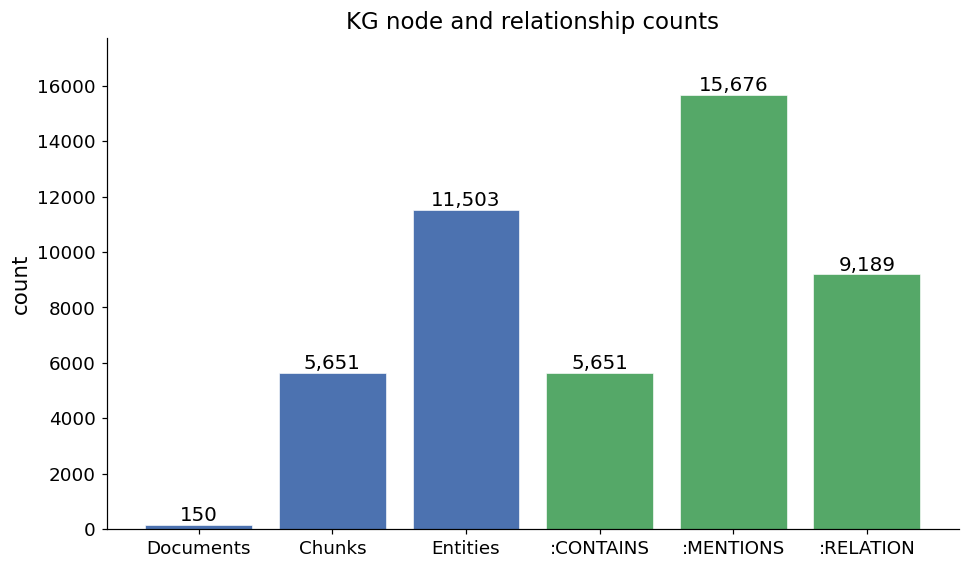

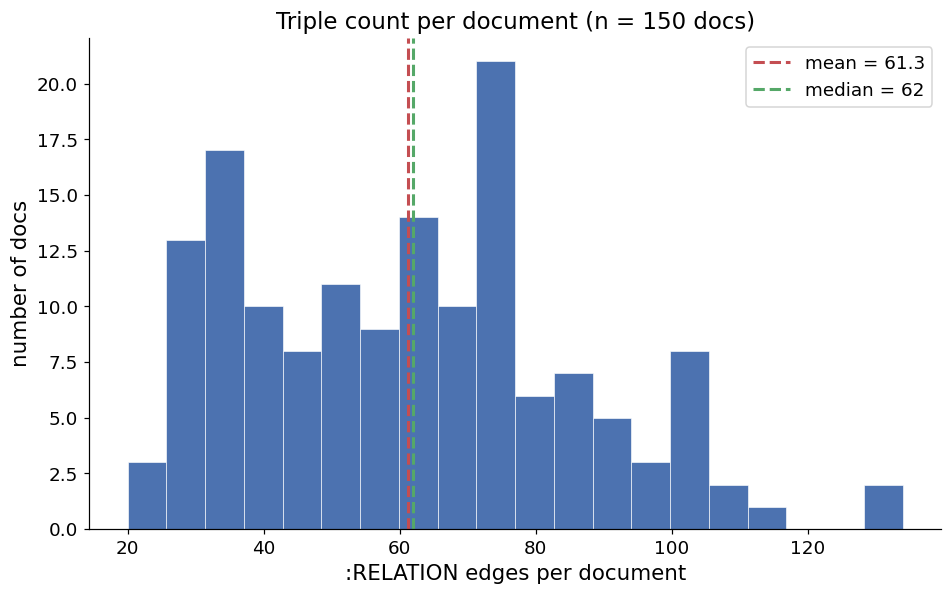

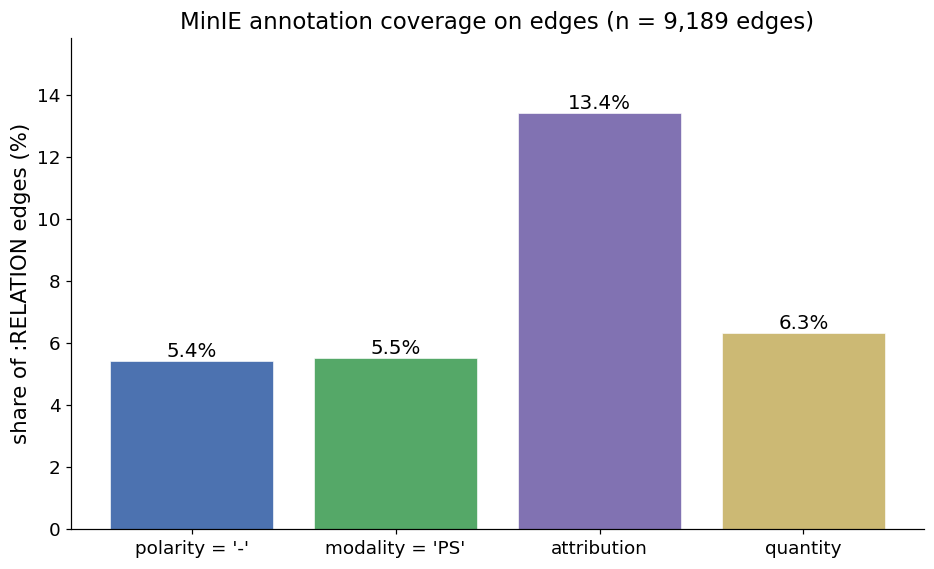

Saved 3 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\03_insert_to_neo4j


In [9]:
import matplotlib.pyplot as plt
import numpy as np

PLOT_DIR = Path("plots/03_insert_to_neo4j")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"

# --- Plot 1: KG node + edge counts ---
counts = {
    "Documents":  run("MATCH (d:Document) RETURN count(d) AS n")[0]["n"],
    "Chunks":     run("MATCH (c:Chunk) RETURN count(c) AS n")[0]["n"],
    "Entities":   run("MATCH (e:Entity) RETURN count(e) AS n")[0]["n"],
    ":CONTAINS":  run("MATCH ()-[r:CONTAINS]->() RETURN count(r) AS n")[0]["n"],
    ":MENTIONS":  run("MATCH ()-[r:MENTIONS]->() RETURN count(r) AS n")[0]["n"],
    ":RELATION":  run("MATCH ()-[r:RELATION]->() RETURN count(r) AS n")[0]["n"],
}
fig, ax = plt.subplots(figsize=(10, 5.8))
node_color = [C_BLUE, C_BLUE, C_BLUE, C_GREEN, C_GREEN, C_GREEN]
bars = ax.bar(list(counts.keys()), list(counts.values()), color=node_color, edgecolor="white", linewidth=0.4)
for bar, v in zip(bars, counts.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:,}", ha="center", va="bottom")
ax.set_ylabel("count")
ax.set_title("KG node and relationship counts")
ax.set_ylim(0, max(counts.values()) * 1.13)
fig.savefig(PLOT_DIR / "kg_counts.png")
plt.show()

# --- Plot 2: triples per doc ---
trip_per_doc = [r["n"] for r in run(
    "MATCH (d:Document) "
    "OPTIONAL MATCH ()-[rel:RELATION {doc_id: d.doc_id}]->() "
    "RETURN d.doc_id AS doc_id, count(rel) AS n"
)]
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.hist(trip_per_doc, bins=20, color=C_BLUE, edgecolor="white", linewidth=0.4)
mean_t = sum(trip_per_doc) / len(trip_per_doc)
sorted_t = sorted(trip_per_doc)
med_t = sorted_t[len(sorted_t) // 2]
ax.axvline(mean_t, color=C_RED, linestyle="--", linewidth=2.0, label=f"mean = {mean_t:.1f}")
ax.axvline(med_t, color=C_GREEN, linestyle="--", linewidth=2.0, label=f"median = {med_t}")
ax.set_xlabel(":RELATION edges per document")
ax.set_ylabel("number of docs")
ax.set_title(f"Triple count per document (n = {len(trip_per_doc)} docs)")
ax.legend()
fig.savefig(PLOT_DIR / "triples_per_doc.png")
plt.show()

# --- Plot 3: MinIE distribution on :RELATION ---
total_rel = run("MATCH ()-[r:RELATION]->() RETURN count(r) AS n")[0]["n"]
shares = {
    "polarity = '-'":   run("MATCH ()-[r:RELATION {polarity: '-'}]->() RETURN count(r) AS n")[0]["n"] / total_rel * 100,
    "modality = 'PS'":  run("MATCH ()-[r:RELATION {modality: 'PS'}]->() RETURN count(r) AS n")[0]["n"] / total_rel * 100,
    "attribution":      run("MATCH ()-[r:RELATION]->() WHERE r.attribution IS NOT NULL RETURN count(r) AS n")[0]["n"] / total_rel * 100,
    "quantity":         run("MATCH ()-[r:RELATION]->() WHERE r.quantity IS NOT NULL RETURN count(r) AS n")[0]["n"] / total_rel * 100,
}
fig, ax = plt.subplots(figsize=(10, 5.8))
colors = [C_BLUE, C_GREEN, C_PURPLE, C_YELLOW]
bars = ax.bar(list(shares.keys()), list(shares.values()), color=colors, edgecolor="white", linewidth=0.4)
for bar, v in zip(bars, shares.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, v, f"{v:.1f}%", ha="center", va="bottom")
ax.set_ylabel("share of :RELATION edges (%)")
ax.set_title(f"MinIE annotation coverage on edges (n = {total_rel:,} edges)")
ax.set_ylim(0, max(shares.values()) * 1.18)
fig.savefig(PLOT_DIR / "minie_edge_distribution.png")
plt.show()

print(f"Saved 3 plots to {PLOT_DIR.resolve()}")

In [10]:
driver.close()
print("Driver closed.")

Driver closed.
